# Training Models in Machine Learning

## Understanding Models

Machine Learning models can often be treated as black boxes. You can get good results without knowing the implementation details, but understanding how models work helps to:

- Choose the right model  
- Pick the appropriate training algorithm  
- Select suitable hyperparameters  
- Debug issues and analyze errors efficiently  



---

## Linear Regression

A linear regression model predicts an output as a weighted sum of input features plus a bias term:

$$
y = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_n x_n
$$

Vectorized form:

$$
\hat{y} = h_\theta(x) = \theta \cdot x
$$

Where:

- $\theta$ = parameter vector $(\theta_0$ = bias term, $\theta_1 \dots \theta_n$ = feature weights)  
- $x$ = input feature vector $(x_0 = 1)$  
- $\theta \cdot x$ = dot product  
- $h_\theta$ = hypothesis function  

Using column vectors:

$$
\hat{y} = \theta^\top x
$$

- $\theta^\top$ = transpose of $\theta$  
- $\theta^\top x$ = matrix multiplication (same as dot product)  

---

## Training Linear Regression

Training = finding parameters $\theta$ that best fit the training data.

- Performance measure: **Mean Squared Error (MSE)**  

$$
\text{MSE} = \frac{1}{m} \sum_{i=1}^m (\hat{y}^{(i)} - y^{(i)})^2
$$

Minimizing MSE is equivalent to minimizing RMSE.  

Two main training methods:

1. **Closed-form solution**: compute $\theta$ directly  
2. **Gradient Descent (GD)**: iteratively adjust $\theta$ to minimize MSE  
   - Variants: Batch GD, Mini-batch GD, Stochastic GD  

---

## Polynomial Regression

- Extension of Linear Regression to fit **nonlinear datasets**  
- More parameters → higher risk of **overfitting**  
- Detect overfitting using **learning curves**  
- Reduce overfitting using **regularization techniques**  

---

## Summary

- **Linear Regression**: predicts a weighted sum of features  
- **Polynomial Regression**: fits nonlinear relationships  
- **Training**: minimize error to find optimal parameters  
- **Gradient Descent**: iterative optimization method  
- Understanding the math helps with model selection, training, and debugging


# The Normal Equation

The **Normal Equation** provides a closed-form solution to find the parameter vector $\theta$  
that minimizes the cost function in Linear Regression. You do **not** need to use Gradient Descent.

$$
\theta = (X^\top X)^{-1} X^\top y
$$

Where:

- $\theta$ = parameter vector that minimizes the cost function  
- $X$ = design matrix (with a column of 1s for the bias term)  
- $y$ = vector of target values $[y^{(1)}, y^{(2)}, \dots, y^{(m)}]^\top$  

---

## Example: Generate Linear Data


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Random linear-looking data
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)


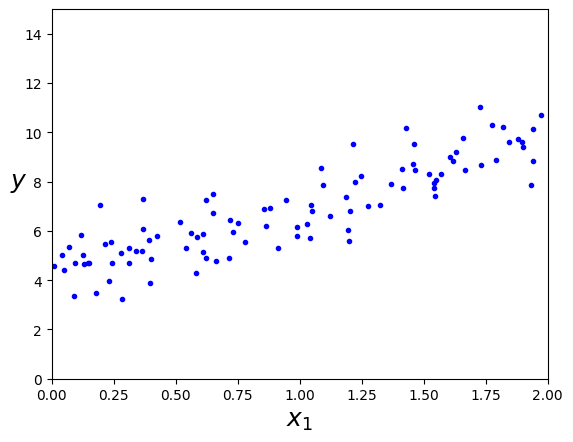

In [2]:
plt.plot(X, y, "b.")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([0, 2, 0, 15])
#save_fig("generated_data_plot")
plt.show()

## Compute θ Using the Normal Equation
We can compute $\theta$ directly using the Normal Equation.  
We will use `np.linalg.inv()` for the matrix inverse and `.dot()` for matrix multiplication.



In [3]:
X[0]

array([0.74908024])

In [6]:
X_b[0]

array([1.        , 0.74908024])

In [5]:
# Add bias term x0 = 1 to each instance
X_b = np.c_[np.ones((100, 1)), X]

# Compute theta using the Normal Equation
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

theta_best


array([[4.21509616],
       [2.77011339]])


The original function was $y = 4 + 3x_1 + \text{noise}$.  
The estimated parameters are close to the true values: $\theta_0 \approx 4.215$ and $\theta_1 \approx 2.77$,  
but the Gaussian noise prevents exact recovery.

---

## Making Predictions
We can now use $\theta$ to predict new values:



In [10]:
X_new = np.array([[-1.1], [2.2]])
X_new_b = np.c_[np.ones((2, 1)), X_new]  # add x0 = 1 to each instance
y_predict = X_new_b.dot(theta_best)
y_predict


array([[ 1.16797143],
       [10.30934561]])

In [11]:
X_new

array([[-1.1],
       [ 2.2]])

In [14]:
X_b[0]

array([1.        , 0.74908024])

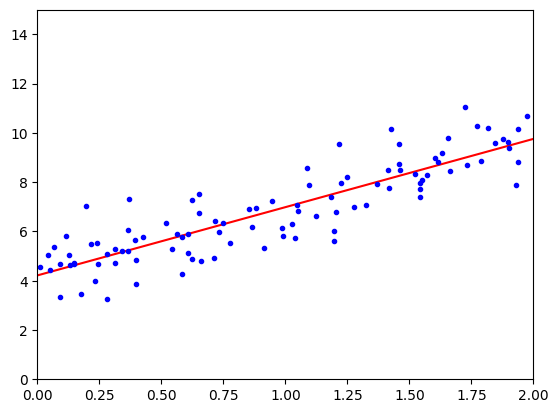

In [9]:
plt.plot(X_new, y_predict, "r-")
plt.plot(X, y, "b.")
plt.axis([0, 2, 0, 15])
plt.show()

### Gradient Descent

Gradient Descent is a general optimization algorithm used to find optimal solutions by **iteratively tweaking parameters** to minimize a cost function.

#### Intuition
Imagine you are lost in the mountains in dense fog. You can only feel the slope under your feet. To reach the bottom of the valley quickly, you take **steps in the direction of the steepest slope downward**. 

This is exactly what Gradient Descent does:

- It computes the **gradient** of the cost function with respect to the parameter vector $$\theta$$.
- It moves $\theta$ in the direction that decreases the cost function.
- When the gradient reaches zero, a minimum is found.

#### Process
1. Start by **randomly initializing** $\theta$.
2. Gradually improve $\theta$ by taking **small steps** toward the direction that reduces the cost (e.g., MSE).
3. Repeat until convergence to a minimum.

This method works for many optimization problems, especially in Machine Learning.

![Gradient Descent Illustration](gradient.png)
*Figure: Gradient Descent iteratively moves toward the minimum of a function.*


An important parameter in Gradient Descent is the size of the steps,   
determined by the learning rate hyperparameter.   

If the learning rate is too small, then the algorithm  
will have to go through many iterations to converge,    
which will take a long time 

![caption](gr2.png)

On the other hand, if the learning rate is too high,   
you might jump across the valley and end up on the other side,  
possibly even higher up than you were before. This  
might make the algorithm diverge, with larger and larger values,   
failing to find a good
solution

![caption](gr3.png)

Finally, not all cost functions look like nice, regular bowls.   
There may be holes, ridges, plateaus, and all sorts of irregular   
terrains, making convergence to the minimum dif‐
ficult.   
Figure 4-6 shows the two main challenges with Gradient Descent.   
If the random initialization starts the algorithm on the left, then   
it will converge to a local
minimum, which is not as good as the global minimum.   
If it starts on the right, then it
will take a very long time to cross the plateau.  
And if you stop too early, you will
never reach the global minimum.

![caption](gr4.png)

## 🧮 Convexity of the MSE Cost Function in Linear Regression

The **Mean Squared Error (MSE)** cost function for a Linear Regression model is a **convex function**.  

This means that for any two points on the curve, the line segment joining them **never crosses the curve**.  
Formally, a function $ f 4 is **convex** if for all $ \theta_1, \theta_2 \in \mathbb{R}^n $ and for all $ \lambda \in [0, 1] $:
$$
f(\lambda \theta_1 + (1 - \lambda)\theta_2) \leq 
\lambda f(\theta_1) + (1 - \lambda)f(\theta_2).
$$

---

### 🧩 Consequences of Convexity

Because the MSE cost function is convex:

- There are **no local minima**, only **one global minimum**.
- The function is **continuous** and its **slope changes smoothly**.
- Therefore, **Gradient Descent** is guaranteed to approach *arbitrarily close* to the **global minimum**,  
  as long as:
  - the **learning rate** is not too high, and  
  - the algorithm runs for a sufficient number of iterations.

---

### 🏔️ Intuitive Picture — The "Bowl" Shape

The cost function has the shape of a **bowl**, formally known as a **convex quadratic surface**.

However, if features have very different scales, the bowl can become **elongated**.  
This happens because each parameter $ \theta_i $ affects the cost function on a different scale.

> Since feature 1 is smaller, it takes a larger change in $ \theta_1 $ to affect the cost function,  
> which is why the bowl is elongated along the $ \theta_1 $-axis.

---

### ⚙️ Mathematical Note
Technically speaking, the **gradient** (derivative) of the MSE cost function is  
**Lipschitz continuous**, meaning that its rate of change is bounded.  
This property ensures that Gradient Descent behaves smoothly and converges predictably.

---

### 📉 Illustration

The following figure illustrates Gradient Descent behavior:

- **Left:** features 1 and 2 are on the same scale → symmetric bowl.  
- **Right:** feature 1 has much smaller values → elongated bowl.

<img src="figure_4_7_gradient_descent_bowl.png" alt="Gradient Descent Bowl Shape" width="600">

**Figure 4-7.** *Effect of feature scaling on the shape of the cost function bowl.*


## 🎯 Gradient Descent Behavior and Feature Scaling

When training a **Linear Regression** model using **Gradient Descent**, the algorithm seeks  
a set of parameters 
$$ \boldsymbol{\theta} = [\theta_0, \theta_1, \dots, \theta_n]^\top $$  
that minimize the **Mean Squared Error (MSE)** cost function:

$$
J(\boldsymbol{\theta}) = \frac{1}{2m} \sum_{i=1}^{m} \left( h_{\boldsymbol{\theta}}(x^{(i)}) - y^{(i)} \right)^2,
$$

where:
- $ m $ — number of training examples,  
- $ h_{\boldsymbol{\theta}}(x) = \boldsymbol{\theta}^\top x $ — hypothesis function (prediction),  
- $ y^{(i)} $ — true output for the $i$-th example.

---

### 🧩 Convexity and Optimization Landscape

The cost function $ J(\boldsymbol{\theta}) $ is **convex**, meaning:
- There is **only one global minimum**.
- Gradient Descent is guaranteed to converge (if learning rate is appropriate).
- The graph of $ J(\boldsymbol{\theta}) $ is shaped like a **bowl** .

A convex function satisfies:
$$
f(\lambda \theta_1 + (1-\lambda)\theta_2) \leq \lambda f(\theta_1) + (1-\lambda)f(\theta_2),
\quad \forall \lambda \in [0,1].
$$


## 🏔️ What Does the "Bowl" Shape Mean?

The "bowl" shape describes how the cost function behaves visually.

- If features are **on the same scale**, the bowl is **symmetric**.
- If features have **very different scales**, the bowl is **elongated**.

In 2D:
- A symmetric bowl → circular contours → fast convergence.
- An elongated bowl → stretched contours → zigzag descent path.

This happens because each feature contributes differently to the cost:
- Smaller feature scales → small parameter changes produce small cost changes.
- Larger feature scales → small parameter changes produce large cost changes.

---

Mathematically, this affects the **Hessian** of \( J(\boldsymbol{\theta}) \), making it ill-conditioned,  
which slows convergence of Gradient Descent.

Thus, **feature scaling** (e.g., using `StandardScaler`) is essential to make all features contribute equally.


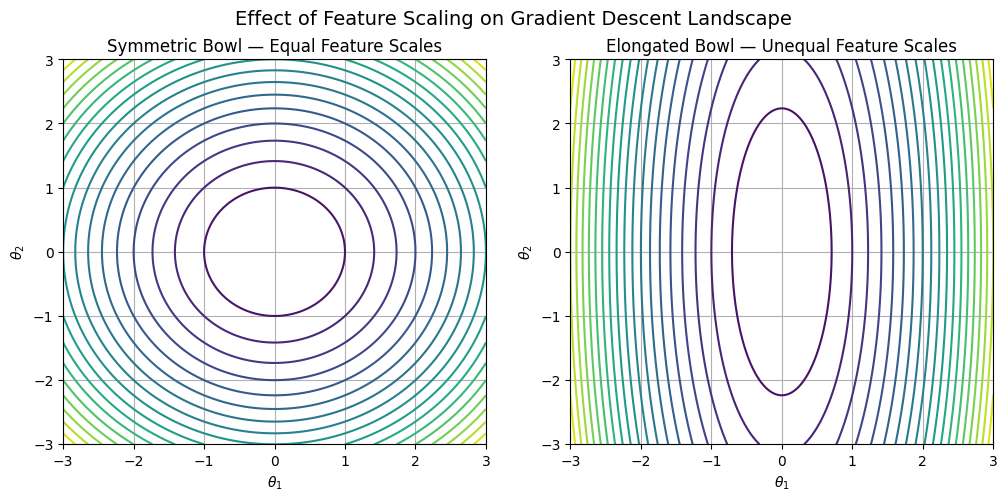

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define the cost function (elliptical bowl)
def cost_function(theta1, theta2, scale=1):
    return theta1**2 + scale * theta2**2

# Create grid
theta1 = np.linspace(-3, 3, 200)
theta2 = np.linspace(-3, 3, 200)
T1, T2 = np.meshgrid(theta1, theta2)

# Compute cost
Z_symmetric = cost_function(T1, T2, scale=1)
Z_elongated = cost_function(T1, T2, scale=0.1)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Symmetric bowl
axes[0].contour(T1, T2, Z_symmetric, levels=20)
axes[0].set_title("Symmetric Bowl — Equal Feature Scales")
axes[0].set_xlabel(r"$\theta_1$")
axes[0].set_ylabel(r"$\theta_2$")
axes[0].grid(True)

# Right: Elongated bowl
axes[1].contour(T1, T2, Z_elongated, levels=20)
axes[1].set_title("Elongated Bowl — Unequal Feature Scales")
axes[1].set_xlabel(r"$\theta_1$")
axes[1].set_ylabel(r"$\theta_2$")
axes[1].grid(True)

plt.suptitle("Effect of Feature Scaling on Gradient Descent Landscape", fontsize=14)
plt.show()


## Batch Gradient Descent

To implement **Gradient Descent**, we must compute the *gradient* of the cost function 
with respect to each model parameter $\theta_j$. 

This tells us how much the cost function will change if we slightly change $\theta_j$.
Mathematically, this is expressed using **partial derivatives**.


### Mathematical Definition

Consider a linear model:

$$
\hat{y}^{(i)} = \theta^T x^{(i)} = \theta_0 + \theta_1 x_1^{(i)} + \dots + \theta_n x_n^{(i)}
$$

and a **Mean Squared Error (MSE)** cost function:

$$
J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \left( \hat{y}^{(i)} - y^{(i)} \right)^2
$$

where:
- $m$ is the number of training samples,
- $x^{(i)}$ is the $i$-th feature vector,
- $y^{(i)}$ is the true label,
- $\hat{y}^{(i)}$ is the predicted value,
- $\theta$ is the parameter vector we want to optimize.


### Partial Derivative of the Cost Function

The **partial derivative** of $J(\theta)$ with respect to $\theta_j$ is:

$$
\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} 
\left( \theta^T x^{(i)} - y^{(i)} \right) x_j^{(i)}
$$

This measures the sensitivity of the cost function to small changes in $\theta_j$.


### Vectorized Gradient Form

To simplify computation, we can represent all partial derivatives at once 
using **matrix-vector notation**. The **gradient vector** is defined as:

$$
\nabla_{\theta} J(\theta) = \frac{1}{m} X^T (X\theta - y)
$$

where:
- $X$ is the design matrix of shape $(m, n+1)$ (including the bias term),
- $y$ is the vector of true labels.


### Gradient Descent Update Rule

In **Batch Gradient Descent**, all training examples are used to compute the gradient 
at each iteration. The parameters are updated as:

$$
\theta := \theta - \eta \nabla_{\theta} J(\theta)
$$

where:
- $\eta > 0$ is the **learning rate**, controlling the step size.


### Interpretation

The update rule means:
- Compute the gradient (the direction of steepest *ascent* of the cost).
- Move $\theta$ in the **opposite** direction (steepest *descent*).
- Repeat until convergence.

If $\eta$ is too small → convergence is very slow.  
If $\eta$ is too large → the algorithm may diverge.


In [12]:
import numpy as np

# Simulated data (with bias term)
X = np.array([[1, 1], [1, 2], [1, 3]])  # shape (3, 2)
y = np.array([1, 2, 3])                 # target vector
theta = np.random.randn(2)              # initial parameters

# Hyperparameters
eta = 0.1
n_iterations = 1000
m = len(y)

for iteration in range(n_iterations):
    gradients = (2/m) * X.T.dot(X.dot(theta) - y)
    theta = theta - eta * gradients

theta


array([-4.2287047e-12,  1.0000000e+00])

### Expected Output and Interpretation

After several iterations, $\theta$ should converge close to:
$$
\theta_0 \approx 0, \quad \theta_1 \approx 1
$$
which corresponds to the line $y = x$ — the best fit for our simple dataset.

This demonstrates how **Batch Gradient Descent** gradually minimizes the MSE 
by updating all parameters simultaneously using the gradient of the cost function.


# Derivation: Partial Derivative of the MSE Cost w.r.t. $(\theta_j\$


## Problem statement

We consider a linear model:

$$
\hat{y}^{(i)} = \theta^\top x^{(i)} = \sum_{k=0}^{n} \theta_k x_k^{(i)},
$$

where $x^{(i)} = (x_0^{(i)}, x_1^{(i)}, \ldots, x_n^{(i)})^\top$ and we include the bias term via $x_0^{(i)} = 1$.

The Mean Squared Error (MSE) cost function (commonly used with a 1/2 factor) is:

$$
J(\theta) = \frac{1}{2m} \sum_{i=1}^m \big( \theta^\top x^{(i)} - y^{(i)} \big)^2.
$$

We want to compute the partial derivative:

$$
\frac{\partial J(\theta)}{\partial \theta_j},
$$

for any $j \in \{0,1,\dots,n\}$.


## Step 1 — Apply derivative to the sum

Start from the definition:

$$
\frac{\partial J(\theta)}{\partial \theta_j}
= \frac{\partial}{\partial \theta_j} \left( \frac{1}{2m} \sum_{i=1}^m \big( \theta^\top x^{(i)} - y^{(i)} \big)^2 \right).
$$

Linearity of differentiation allows moving constants and sums outside the derivative:

$$
\frac{\partial J(\theta)}{\partial \theta_j}
= \frac{1}{2m} \sum_{i=1}^m \frac{\partial}{\partial \theta_j} \left( \big( \theta^\top x^{(i)} - y^{(i)} \big)^2 \right).
$$


## Step 2 — Use the chain rule on each summand

Let $e^{(i)}(\theta) = \theta^\top x^{(i)} - y^{(i)}$. Then each summand is $(e^{(i)}(\theta))^2$.

By the chain rule:

$$
\frac{\partial}{\partial \theta_j} \big( e^{(i)}(\theta)^2 \big)
= 2 \, e^{(i)}(\theta) \cdot \frac{\partial e^{(i)}(\theta)}{\partial \theta_j}.
$$

But $e^{(i)}(\theta) = \sum_{k=0}^n \theta_k x_k^{(i)} - y^{(i)}$. Differentiating with respect to $\theta_j$ yields:

$$
\frac{\partial e^{(i)}(\theta)}{\partial \theta_j} = \frac{\partial}{\partial \theta_j} \left( \sum_{k=0}^n \theta_k x_k^{(i)} - y^{(i)} \right)
= x_j^{(i)}.
$$

So:

$$
\frac{\partial}{\partial \theta_j} \big( e^{(i)}(\theta)^2 \big)
= 2 \, e^{(i)}(\theta) \, x_j^{(i)}.
$$


## Step 3 — Combine and simplify to get the partial derivative

Substitute the chain-rule result into the sum:

$$
\frac{\partial J(\theta)}{\partial \theta_j}
= \frac{1}{2m} \sum_{i=1}^m \big( 2 \, e^{(i)}(\theta) \, x_j^{(i)} \big)
= \frac{1}{m} \sum_{i=1}^m \big( \theta^\top x^{(i)} - y^{(i)} \big) x_j^{(i)}.
$$

Thus we obtain the familiar scalar formula:

$$
\boxed{\;\displaystyle
\frac{\partial J(\theta)}{\partial \theta_j}
= \frac{1}{m} \sum_{i=1}^m \big( \theta^\top x^{(i)} - y^{(i)} \big) x_j^{(i)}
\;}
$$

This is the rate of change of the MSE with respect to parameter $\theta_j$.


## Vectorized form (gradient vector)

Stacking all partial derivatives into a vector gives the full gradient:

$$
\nabla_{\theta} J(\theta) =
\begin{pmatrix}
\frac{\partial J}{\partial \theta_0} \\
\frac{\partial J}{\partial \theta_1} \\
\vdots \\
\frac{\partial J}{\partial \theta_n}
\end{pmatrix}
= \frac{1}{m} X^\top (X\theta - y),
$$

where:
- $X$ is the $m \times (n+1)$ design matrix with rows $(x^{(i)})^\top$,
- $y$ is the $m$-vector of targets,
- $X\theta$ is the $m$-vector of predictions $\theta^\top x^{(i)}$.

The gradient update for Batch Gradient Descent is:

$$
\theta \leftarrow \theta - \eta \nabla_{\theta} J(\theta)
= \theta - \frac{\eta}{m} X^\top (X\theta - y).
$$


In [13]:
import numpy as np

# Small example with bias term included
X = np.array([
    [1.0, 1.0, 2.0],   # x^(1): [1, x1, x2]
    [1.0, 2.0, 0.5],   # x^(2)
    [1.0, 3.0, 4.0],   # x^(3)
])
y = np.array([3.0, 2.5, 7.0])

# Random theta for demonstration
theta = np.array([0.1, 0.2, -0.1])

m = X.shape[0]

# Compute gradient using the derived closed form
preds = X.dot(theta)               # vector of theta^T x^(i)
grad_closed = (1/m) * X.T.dot(preds - y)

# Numerical gradient (finite differences) to verify
epsilon = 1e-6
grad_num = np.zeros_like(theta)
for j in range(len(theta)):
    theta_plus = theta.copy()
    theta_minus = theta.copy()
    theta_plus[j] += epsilon
    theta_minus[j] -= epsilon
    J_plus = (1/(2*m)) * np.sum((X.dot(theta_plus) - y)**2)
    J_minus = (1/(2*m)) * np.sum((X.dot(theta_minus) - y)**2)
    grad_num[j] = (J_plus - J_minus) / (2*epsilon)

grad_closed, grad_num, np.allclose(grad_closed, grad_num, atol=1e-6)


(array([ -3.88333333,  -9.03333333, -11.20833333]),
 array([ -3.88333333,  -9.03333333, -11.20833333]),
 True)

# Stochastic Gradient Descent (SGD)


## Motivation

**Batch Gradient Descent (BGD)** computes the gradient of the cost function using **all training examples** at each iteration:

$$
\nabla_\theta J(\theta) = \frac{1}{m} X^\top (X\theta - y)
$$

When the training set is very large (e.g., millions of samples), this becomes computationally expensive, as every parameter update requires scanning the entire dataset.

**Stochastic Gradient Descent (SGD)** offers a solution:

- Instead of computing the gradient over all examples,
- It picks **one random instance** (or a small mini-batch) at each iteration.
- It updates the parameters immediately using that single example’s gradient.

Thus, SGD can perform **many more updates per second** and start learning patterns faster.


## Mathematical Formulation

Let the cost for a single training example $(x^{(i)}, y^{(i)})$ be:

$$
J^{(i)}(\theta) = \frac{1}{2}\big(h_\theta(x^{(i)}) - y^{(i)}\big)^2
$$

where $ h_\theta(x^{(i)}) = \theta^\top x^{(i)} $.

Then, its gradient with respect to parameter \( \theta_j \) is:

$$
\frac{\partial J^{(i)}(\theta)}{\partial \theta_j}
= \big(h_\theta(x^{(i)}) - y^{(i)}\big) x^{(i)}_j
$$

The **SGD update rule** is then:

$$
\boxed{
\theta \leftarrow \theta - \eta \, \nabla_\theta J^{(i)}(\theta)
= \theta - \eta \, (h_\theta(x^{(i)}) - y^{(i)}) \, x^{(i)}
}
$$

where:
- $\eta > 0$ is the **learning rate**,
- $x^{(i)}$ is the randomly selected training sample at this iteration.


## Intuition and Trade-offs

- **Speed**: Each update uses just one training example, so it's much faster per step.
- **Noise**: Since it uses random samples, the updates are noisy — the cost function “bounces” up and down instead of smoothly descending.
- **Convergence**: The path is irregular, but on average it heads toward the minimum.
- **Stochasticity helps**: The noise can help the algorithm jump out of shallow local minima or plateaus in non-convex problems (e.g., deep neural networks).
- **Steady-state**: It never fully settles at the exact minimum — it oscillates near it.

To handle oscillations, one can:
1. **Gradually decrease the learning rate** (learning rate scheduling):
   $$
   \eta_t = \frac{t_0}{t + t_1}
   $$
   where $t$ is the iteration number.
2. **Use Mini-batch Gradient Descent**, a compromise between BGD and SGD.


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Generate simple linear data: y = 4 + 3x + noise
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Add bias term
X_b = np.c_[np.ones((100, 1)), X]

# Batch Gradient Descent
eta = 0.1
n_iterations = 1000
m = 100
theta_bgd = np.random.randn(2, 1)

for iteration in range(n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta_bgd) - y)
    theta_bgd -= eta * gradients

# Stochastic Gradient Descent
n_epochs = 50
t0, t1 = 5, 50  # learning schedule hyperparams

def learning_schedule(t):
    return t0 / (t + t1)

theta_sgd = np.random.randn(2, 1)
t = 0

for epoch in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta_sgd) - yi)
        eta = learning_schedule(t)
        theta_sgd -= eta * gradients
        t += 1

theta_bgd, theta_sgd


(array([[4.21509616],
        [2.77011339]]),
 array([[4.18475289],
        [2.73036719]]))

## Observations

- Both BGD and SGD converge to similar parameters.
- SGD requires **many more small updates**, but each update is **cheaper**.
- Due to the learning rate schedule, SGD gradually stabilizes near the optimum.

This stochasticity makes SGD suitable for **online learning**, where data arrives continuously or in large streams.


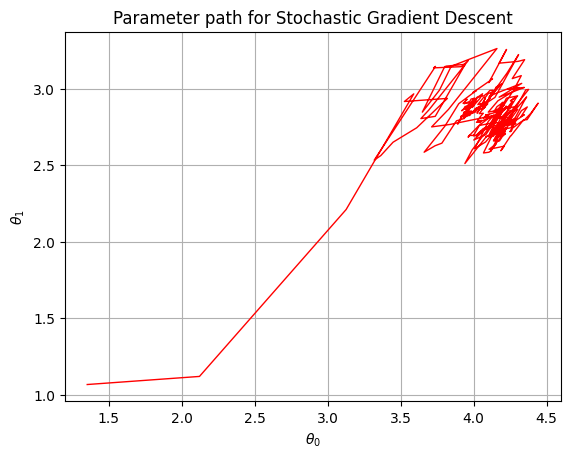

In [6]:
# Demonstrate noisy cost descent path for SGD

def compute_cost(X_b, y, theta):
    m = len(y)
    return (1/(2*m)) * np.sum((X_b.dot(theta) - y)**2)

theta_path_sgd = []
theta = np.random.randn(2, 1)
t = 0
n_epochs = 5

for epoch in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule(t)
        theta -= eta * gradients
        theta_path_sgd.append(theta.copy())
        t += 1

theta_path_sgd = np.array(theta_path_sgd)

plt.plot(theta_path_sgd[:,0], theta_path_sgd[:,1], "r-", linewidth=1)
plt.xlabel(r"$\theta_0$")
plt.ylabel(r"$\theta_1$")
plt.title("Parameter path for Stochastic Gradient Descent")
plt.grid(True)
plt.show()


## Key Takeaway

- **Batch Gradient Descent**: Smooth, deterministic convergence but slow for large datasets.
- **Stochastic Gradient Descent**: Fast, noisy convergence that generalizes well and scales to large datasets.
- **Mini-Batch Gradient Descent**: Balances speed and stability by using small subsets of data per update.

SGD is the foundation for most **modern optimization algorithms** used in deep learning — such as:
- Momentum,
- RMSProp,
- Adam,
which are extensions that control and smooth the stochastic noise to accelerate convergence.


# Mini-Batch Gradient Descent (MBGD)


## Introduction

**Mini-Batch Gradient Descent (MBGD)** is a compromise between:

- **Batch Gradient Descent (BGD)** — uses the **full dataset** at every step.
- **Stochastic Gradient Descent (SGD)** — uses **one random sample** per step.

In MBGD:

- At each iteration, the gradient is computed on a **small random subset of the dataset**, called a **mini-batch**.
- This combines the **efficiency of vectorized operations** with the **stochasticity of SGD**.

**Advantages of Mini-Batch GD:**

1. **Hardware optimization**: Small batches allow fast **matrix operations**, especially on GPUs.
2. **Less erratic than SGD**: Parameter updates are smoother since each update is averaged over a mini-batch.
3. **Good convergence**: Walks closer to the minimum than SGD.
4. **Memory efficiency**: Only need a subset of the data in memory at a time.


## Mathematical Formulation

Let a mini-batch contain \(b\) examples:

$$
\mathcal{B} = \{ (x^{(i)}, y^{(i)}) \mid i \in \text{mini-batch} \}, \quad |\mathcal{B}| = b
$$

The **cost function for a mini-batch** is:

$$
J_\mathcal{B}(\theta) = \frac{1}{2b} \sum_{i \in \mathcal{B}} \big( \theta^\top x^{(i)} - y^{(i)} \big)^2
$$

The **gradient with respect to** $\theta_j$ is:

$$
\frac{\partial J_\mathcal{B}(\theta)}{\partial \theta_j} 
= \frac{1}{b} \sum_{i \in \mathcal{B}} \big( \theta^\top x^{(i)} - y^{(i)} \big) x_j^{(i)}
$$

Or in **vectorized form**:

$$
\nabla_\theta J_\mathcal{B}(\theta) = \frac{1}{b} X_\mathcal{B}^\top (X_\mathcal{B} \theta - y_\mathcal{B})
$$

The **update rule** is:

$$
\theta \leftarrow \theta - \eta \, \nabla_\theta J_\mathcal{B}(\theta)
$$

where $X_\mathcal{B}$ and $y_\mathcal{B}$ are the **features and labels of the mini-batch**.


## Intuition and Trade-offs

- **Parameter path**: MBGD updates are **less noisy than SGD** because the gradient is averaged over multiple examples.
- **Local minima**: Slightly harder to escape local minima than SGD (important in non-convex problems, e.g., deep learning).
- **Efficiency**: Benefits from **GPU acceleration** due to matrix-vector operations on mini-batches.
- **Memory**: Only need a small batch in memory at a time, enabling training on **large datasets**.

**Comparison of GD algorithms**:

| Algorithm | Step Size | Stability | Speed | Memory |
|-----------|-----------|-----------|-------|--------|
| Batch GD  | Full dataset | Smooth, deterministic | Slow | High |
| SGD       | Single example | Noisy | Fast | Low |
| Mini-Batch GD | Small batch | Moderately smooth | Fast | Moderate |


In [15]:
import numpy as np

# Generate linear data
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Add bias term
X_b = np.c_[np.ones((100,1)), X]

# Hyperparameters
eta = 0.1
n_epochs = 50
batch_size = 20
m = len(y)
theta = np.random.randn(2,1)

# Mini-Batch Gradient Descent
for epoch in range(n_epochs):
    shuffled_indices = np.random.permutation(m)
    X_b_shuffled = X_b[shuffled_indices]
    y_shuffled = y[shuffled_indices]
    
    for i in range(0, m, batch_size):
        xi = X_b_shuffled[i:i+batch_size]
        yi = y_shuffled[i:i+batch_size]
        gradients = 2/xi.shape[0] * xi.T.dot(xi.dot(theta) - yi)
        theta -= eta * gradients

theta


array([[4.22191654],
       [2.7700278 ]])

## Observations

1. MBGD converges faster than SGD on average because it reduces noise by averaging over mini-batches.
2. The parameter updates are **smoother** than SGD but not as smooth as Batch GD.
3. Mini-batch size is a **hyperparameter**:
   - Small batch → more stochasticity, can escape shallow local minima.
   - Large batch → smoother updates, but slower per iteration and less regularization effect.
4. MBGD is widely used in **deep learning**, often with batch sizes like 32, 64, or 128.


## Visualization of Gradient Descent Paths

- Batch GD → smooth path, stops exactly at minimum.
- SGD → noisy path, oscillates around minimum.
- Mini-Batch GD → moderately noisy, closer to minimum than SGD, benefits from matrix-vector acceleration.

> In linear regression, all methods eventually reach near the global minimum if the learning rate is chosen properly.
